## Импорты

In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline
import hdbscan

import warnings
warnings.filterwarnings('ignore')

In [38]:
def optimize_memory_usage(df: pd.DataFrame, print_size: bool=True) -> pd.DataFrame:
        '''
        Функция для уменьшения объема занимаемой памяти. очень актуально в ситуации с небольшим объемом памяти
        '''
        numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
        # Размер занимаемой памяти до оптимизации (в Мб)
        before_size = df.memory_usage().sum() / 1024**2    
        for column in df.columns:
            column_type = df[column].dtypes
            if column_type in numerics:
                column_min = df[column].min()
                column_max = df[column].max()
                if str(column_type).startswith('int'):
                    if column_min > np.iinfo(np.int8).min and column_max < np.iinfo(np.int8).max:
                        df[column] = df[column].astype(np.int8)
                    elif column_min > np.iinfo(np.int16).min and column_max < np.iinfo(np.int16).max:
                        df[column] = df[column].astype(np.int16)
                    elif column_min > np.iinfo(np.int32).min and column_max < np.iinfo(np.int32).max:
                        df[column] = df[column].astype(np.int32)
                    elif column_min > np.iinfo(np.int64).min and column_max < np.iinfo(np.int64).max:
                        df[column] = df[column].astype(np.int64)  
                else:
                    if column_min > np.finfo(np.float32).min and column_max < np.finfo(np.float32).max:
                        df[column] = df[column].astype(np.float32)
                    else:
                        df[column] = df[column].astype(np.float64)    

        after_size = df.memory_usage().sum() / 1024**2
        if print_size: print('Размер использования памяти: до {:5.2f} Mb - после {:5.2f} Mb ({:.1f}%)'
                            .format(before_size, after_size, 100 * (before_size - after_size) / before_size))
        return df
    
def set_frame_style(df, caption=""):
    """Зададим стиль вывода по нашим данным.
    """
    return df.style.background_gradient(cmap='Grays').set_caption(caption).set_table_styles([{
    'selector': 'caption',
    'props': [
        ('color', 'Black'),
        ('font-size', '18px'),
        ('font-weight','bold')
    ]}])

def check_data(data, title):
    cols = data.columns.to_list()
    display(set_frame_style(data[cols].head(),f'{title}: Первые 5 строк датафрейма'))
    display(set_frame_style(data[cols].describe(),f'{title}: Статистики'))
    display(set_frame_style(data[cols].nunique().to_frame().rename({0:'Уникальные значения'}, axis=1).transpose(), f'{title}: Unique Value Counts In Each Column'))
    display(set_frame_style(data[cols].isna().sum().to_frame().transpose(), f'{title}:Столбцы с пропусками'))

def feature_statistics(df, iqr_coef=1.5, round_digits=4):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    rows = []

    for col in numeric_df.columns:
        s = numeric_df[col].dropna()

        if len(s) == 0:
            rows.append({
                'feature': col,
                'dtype': numeric_df[col].dtype,
                'count': 0,
                'missing': numeric_df[col].isna().sum(),
                'missing_%': 100.0,
                'unique': 0,
                'mean': np.nan,
                'std': np.nan,
                'min': np.nan,
                'q1': np.nan,
                'median': np.nan,
                'q3': np.nan,
                'max': np.nan,
                'skew': np.nan,
                'kurtosis': np.nan,
                'iqr': np.nan,
                'outliers_iqr': np.nan,
                'outliers_iqr_%': np.nan
            })
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_coef * iqr
        upper = q3 + iqr_coef * iqr

        outliers = ((s < lower) | (s > upper)).sum()

        rows.append({
            'feature': col,
            'dtype': numeric_df[col].dtype,
            'count': len(s),
            'missing': numeric_df[col].isna().sum(),
            'missing_%': round(numeric_df[col].isna().mean() * 100, round_digits),
            'unique': s.nunique(),
            'mean': round(s.mean(), round_digits),
            'std': round(s.std(), round_digits),
            'min': round(s.min(), round_digits),
            'q1': round(q1, round_digits),
            'median': round(s.median(), round_digits),
            'q3': round(q3, round_digits),
            'max': round(s.max(), round_digits),
            'skew': round(s.skew(), round_digits),
            'kurtosis': round(s.kurtosis(), round_digits),
            'iqr': round(iqr, round_digits),
            'outliers_iqr': int(outliers),
            'outliers_iqr_%': round(outliers / len(s) * 100, round_digits)
        })

    stats_df = pd.DataFrame(rows)
    return stats_df
    

### Загрузка данных

In [34]:
path = "/Users/phil/Downloads/Run200_Wave_0_1.txt"

df = pd.read_csv(path, sep=' ', header=None, skipinitialspace=True)

In [35]:
display(df.head())
df.tail()
print()
df.style.background_gradient(cmap=cm)
df.info(memory_usage='deep')

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN



<class 'pandas.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


In [36]:
optimize_memory_usage(df)

Размер использования памяти: до 90.46 Mb - после 22.88 Mb (74.7%)


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23474,199983883854,794,100,500,14826,14827,14825,14818,14825,14827,...,14828,14825,14819,14826,14828,14822,14824,14824,14827,NaN
23475,199992116348,833,1252,500,14824,14823,14819,14828,14819,14824,...,14826,14824,14814,14814,14818,14816,14822,14819,14817,NaN
23476,199993451438,716,1055,500,14822,14822,14824,14820,14823,14828,...,14817,14815,14817,14818,14817,14816,14819,14817,14820,NaN
23477,199999096118,505,323,500,14824,14823,14824,14822,14821,14824,...,14824,14827,14822,14825,14824,14822,14820,14819,14824,NaN


Были загружены данные. Датасет содержит 23479 строк и 505 столбцов. Был оптимизирован размер использования памяти на 75%. 

### анализ данных

In [39]:
check_data(df, 'DATA')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504
Уникальные значения,23479,276,2079,1,23,24,23,25,23,24,23,23,23,24,24,23,23,25,23,24,22,22,24,24,23,23,23,24,22,25,24,22,23,23,24,23,23,24,21,22,24,21,22,22,24,22,22,23,23,24,22,24,23,22,23,25,25,23,24,23,25,25,24,22,23,23,25,24,23,21,23,23,23,24,25,24,24,23,22,23,23,23,23,23,23,23,24,22,23,23,22,23,23,24,23,22,23,25,23,23,25,22,22,22,25,23,21,23,23,23,24,22,23,22,23,23,23,23,25,23,23,23,22,22,23,24,23,23,23,23,25,23,24,26,23,23,24,24,22,22,23,23,22,23,23,23,35,60,96,141,165,318,1616,3829,5513,5933,5557,4841,4042,3291,2628,2128,1746,1393,1141,930,811,696,617,552,496,452,407,375,340,321,301,291,268,259,256,241,228,220,211,204,194,195,182,178,176,167,162,163,159,154,150,150,141,138,141,134,128,125,129,125,124,120,117,117,114,113,109,102,106,100,105,100,103,100,95,97,93,90,90,92,87,84,86,84,82,85,82,81,80,76,80,78,78,79,77,75,73,75,72,72,72,73,70,71,72,68,73,67,67,68,65,67,65,69,66,61,61,61,62,63,63,62,62,63,59,60,58,62,61,59,55,56,59,58,54,56,56,57,51,51,53,56,54,55,56,56,57,59,54,52,51,51,53,51,53,52,51,48,51,48,50,50,47,49,47,47,46,48,50,48,44,45,47,45,50,48,49,45,48,48,46,47,43,42,44,47,45,43,42,44,42,42,44,44,44,44,44,43,40,40,44,39,45,39,43,39,41,41,44,42,44,40,39,43,40,43,41,42,39,40,43,40,43,39,39,41,40,43,40,40,42,40,41,39,39,40,40,40,41,42,41,39,41,41,39,43,40,41,38,41,41,41,35,38,40,39,39,36,38,37,38,40,34,38,37,39,37,38,39,41,38,37,36,37,38,35,36,40,38,35,34,35,40,35,35,36,35,32,35,35,35,35,35,37,34,36,36,35,33,35,33,32,33,37,34,34,34,34,35,34,35,36,34,35,36,32,32,34,30,33,33,32,32,33,35,33,36,33,35,34,33,33,34,33,35,35,34,36,35,34,34,34,36,33,34,30,33,34,36,34,33,34,32,32,30,29,30,32,0


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,23479


Удалим служебные колонки и колонки с нулями

In [12]:
df.drop([0, 1, 2, 3, 504], axis=1, inplace=True)
df.head(3)

,4,5,6,7,8,9,10,11,12,13,...,494,495,496,497,498,499,500,501,502,503
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821


Text(0, 0.5, 'bit ADC')

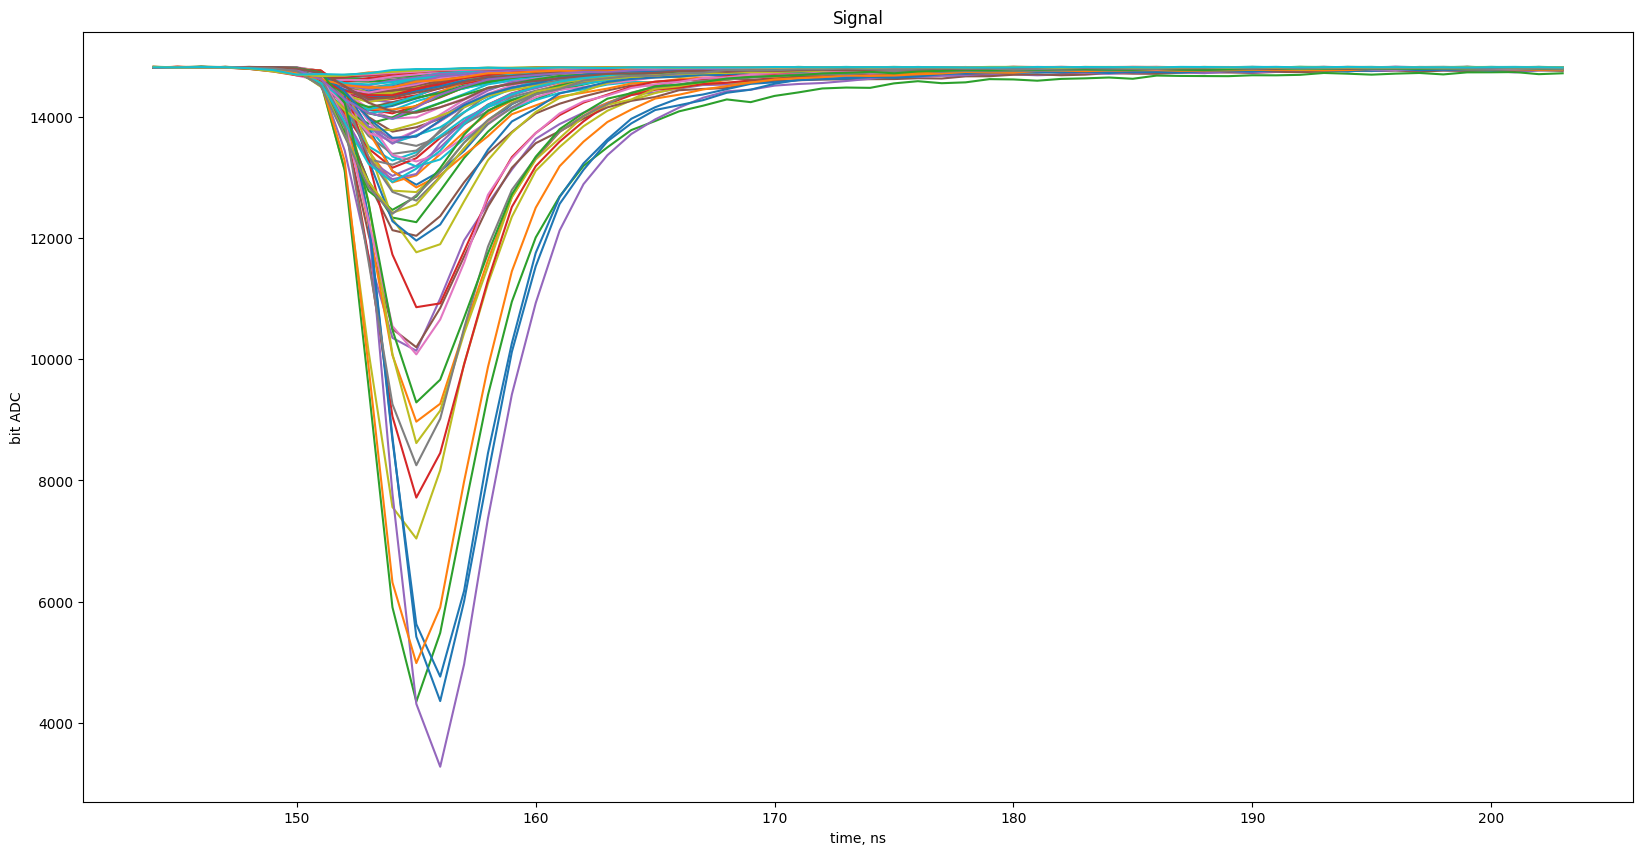

In [13]:
N=range(0,100)
ax = df.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

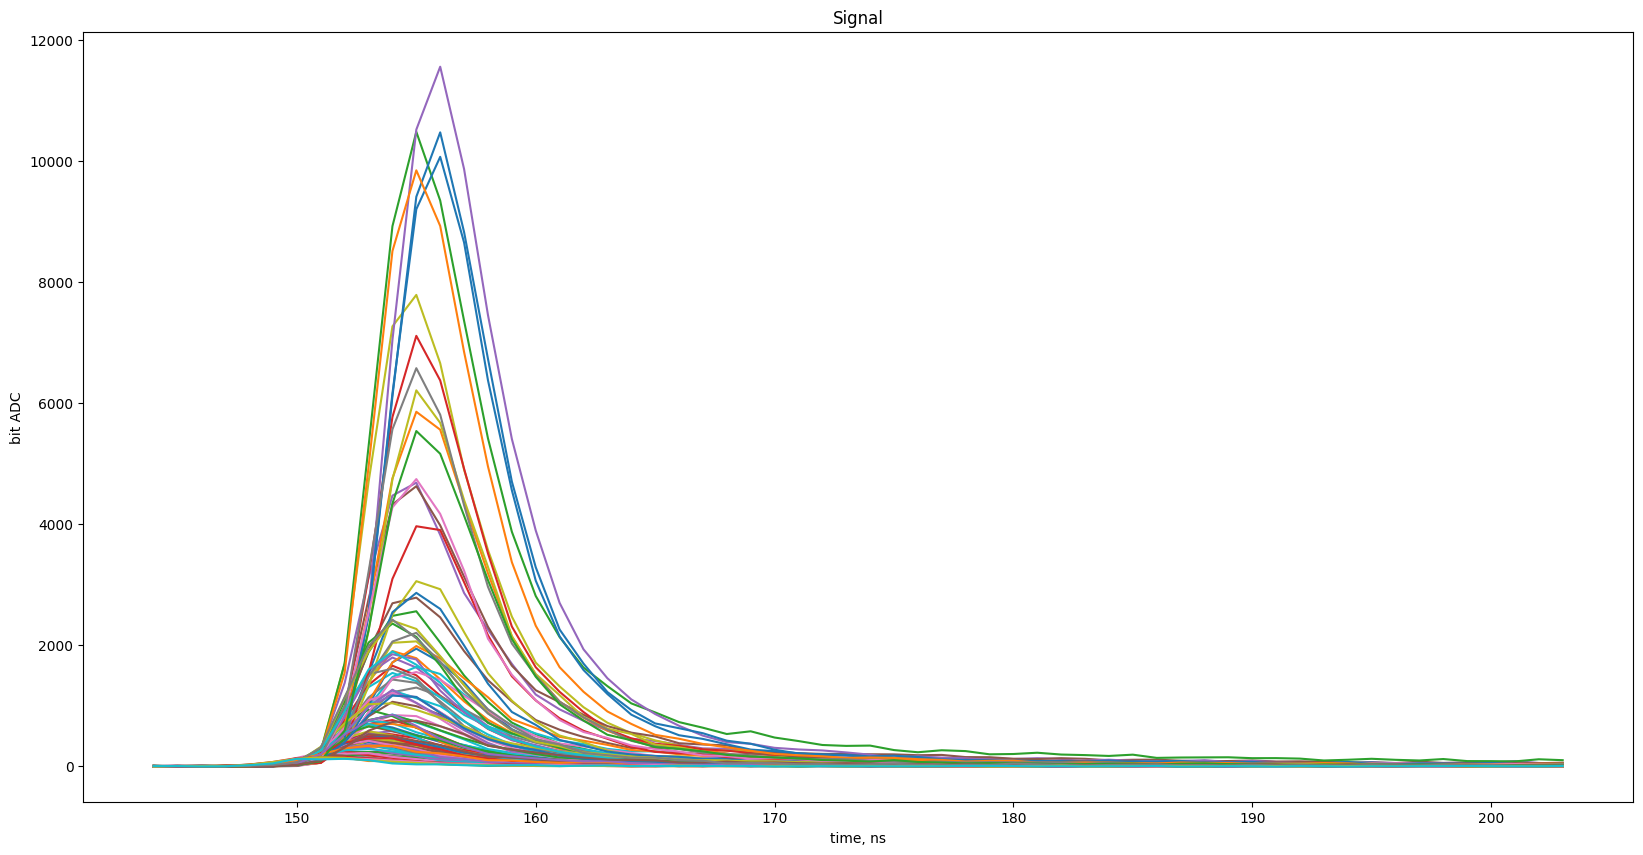

In [14]:
ax = (2**14-df.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Анализ пиков показал: Максимальное значение амплитуды 14835, совпадает с данными статистик, имеются выбросы.

Визуализировать 500 признаков неудобно. Для такого случая создадим сводную статистическую функцию, которая по каждому признаку покажет:

- тип данных,
- число пропусков,
- число уникальных значений,
- среднее,
- стандартное отклонение,
- минимум / максимум,
- квартили,
- асимметрию,
- эксцесс,
- число выбросов по IQR,
- долю выбросов.
- 
Это как раз даст основу для вывода о:

- распределении признаков,
- наличии выбросов,
- масштабе признаков,
- возможной необходимости масштабирования,
- выборе алгоритма.

In [16]:
stats_df = feature_statistics(df)
stats_df.head()

,feature,dtype,count,missing,missing_%,unique,mean,std,min,q1,median,q3,max,skew,kurtosis,iqr,outliers_iqr,outliers_iqr_%
0,4,int16,23479,0,0.0,23,14822.9723,2.8059,14812,14821.0,14823.0,14824.0,14834,0.0718,-0.2293,3.0,491,2.0912
1,5,int16,23479,0,0.0,24,14822.9585,2.8335,14812,14821.0,14823.0,14824.0,14835,0.0517,-0.1476,3.0,539,2.2957
2,6,int16,23479,0,0.0,23,14822.9700,2.8408,14812,14821.0,14823.0,14825.0,14834,0.0450,-0.2191,4.0,49,0.2087
3,7,int16,23479,0,0.0,25,14822.9900,2.8521,14811,14821.0,14823.0,14825.0,14835,0.0679,-0.1964,4.0,54,0.2300
4,8,int16,23479,0,0.0,23,14823.0040,2.8334,14812,14821.0,14823.0,14825.0,14834,0.0348,-0.2294,4.0,48,0.2044


Выводы по статистикам: 

1. Пропусков нет:

- не нужно делать импутацию

- можно сразу переходить к масштабированию и кластеризации;

- структура данных не искажается заменой пропущенных значений.


2. Выбросы есть, но не катастрофические
Максимум 12% выбросов по отдельным признакам — это заметно, но не экстремально.

То есть:
данные нельзя считать полностью “чистыми”;
выбросы могут влиять на алгоритмы, чувствительные к средним значениям и расстояниям;
но это не выглядит как полностью деградировавший датасет.
Вывод:
KMeans может быть чувствителен к таким точкам;
GMM тоже может частично искажаться;
HDBSCAN в этом плане выглядит устойчивее, особенно если предполагается наличие аномальных сигналов.


3. Асимметрия умеренная
Максимальная асимметрия около 1.5 означает, что:

распределения некоторых признаков несимметричны;
но сильной экстремальной ненормальности по большинству признаков, вероятно, нет.
Это не критично, но говорит о том, что:

данные не идеально “гауссовы”;
алгоритмы, предполагающие красивую эллипсоидную структуру, могут работать не идеально;
всё же GMM можно использовать как сравнение, но не обязательно как единственный основной метод.


4. Есть различие в разбросах
Это важный момент.

Если масштабы признаков разные, то алгоритмы на расстояниях будут смещаться в сторону признаков с большими значениями.

Значит:
масштабирование обязательно.


Какой вывод по выбору алгоритма:

масштабирование;

снижение размерности через PCA;

сравнение нескольких алгоритмов.

In [17]:
def get_high_correlations(df, method='pearson', threshold=0.8):
    """
    Возвращает таблицу пар признаков, у которых абсолютная корреляция выше threshold.
    """
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    corr_matrix = numeric_df.corr(method=method).abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    high_corr_pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'abs_corr'})
        .sort_values(by='abs_corr', ascending=False)
    )

    high_corr_pairs = high_corr_pairs[high_corr_pairs['abs_corr'] >= threshold]
    return high_corr_pairs

In [20]:
high_corr = get_high_correlations(df, threshold=0.8)
high_corr.head(10)

,feature_1,feature_2,abs_corr
77155,158,159,0.998881
76654,157,158,0.998596
77656,159,160,0.998429
78157,160,161,0.998035
78658,161,162,0.997800
76153,156,157,0.997797
79159,162,163,0.997160
76655,157,159,0.996733
77156,158,160,0.996496
79660,163,164,0.996279


## график корреляции

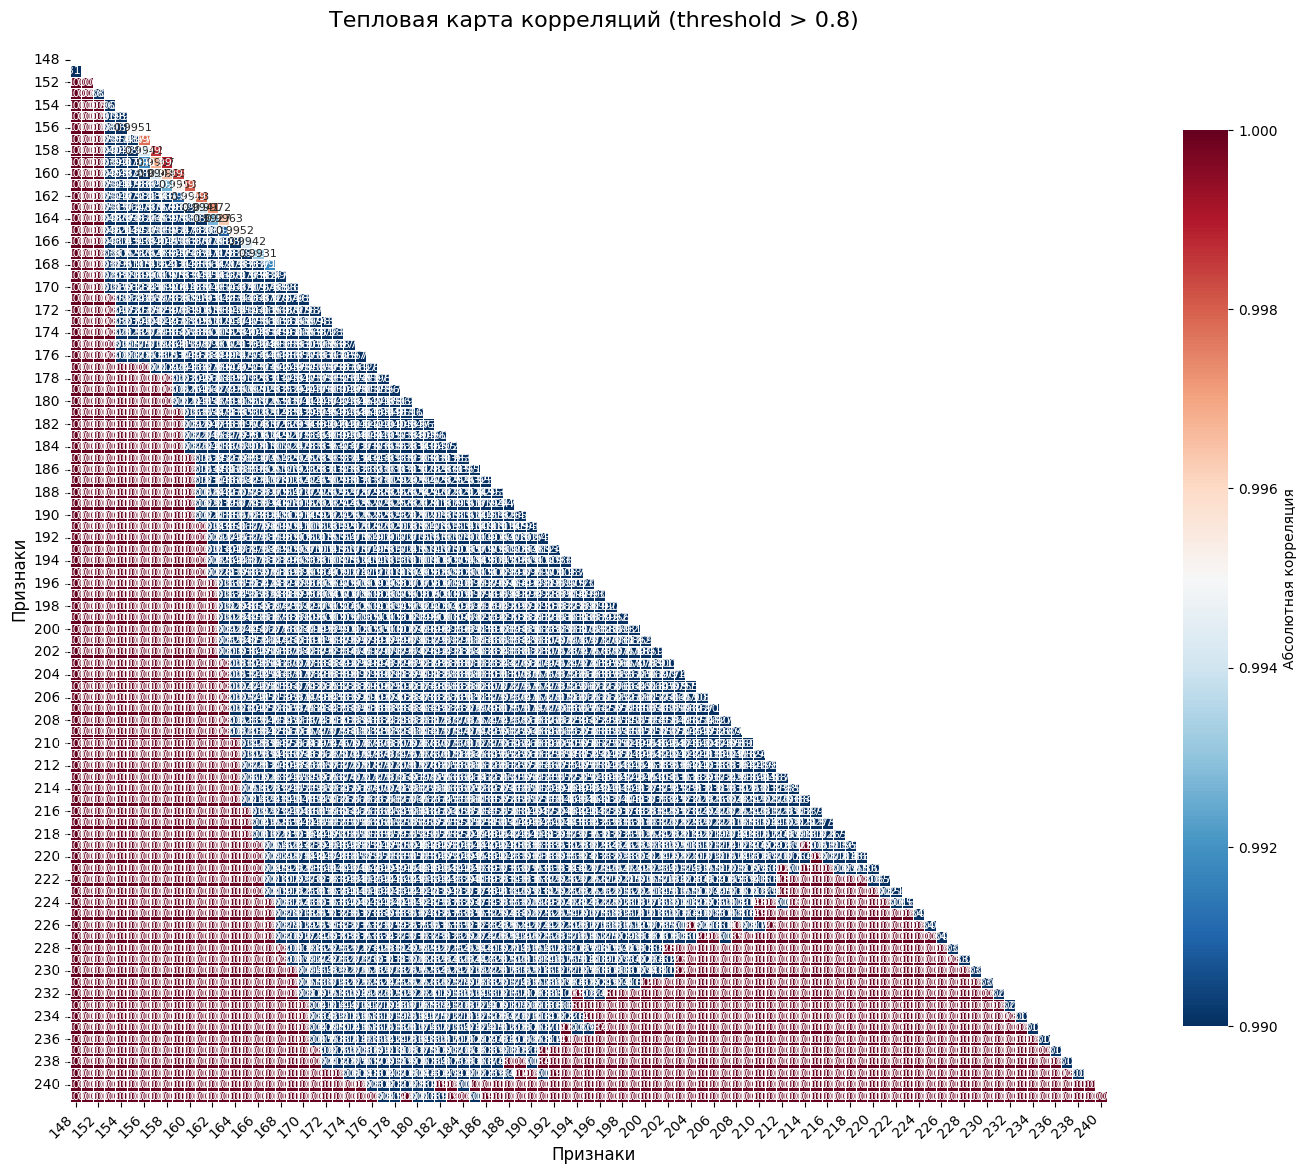

In [21]:
all_features = list(set(high_corr['feature_1'].tolist() + high_corr['feature_2'].tolist()))
n_features = len(all_features)

corr_matrix = pd.DataFrame(np.ones((n_features, n_features)), 
                          index=all_features, 
                          columns=all_features)

for _, row in high_corr.iterrows():
    f1, f2, corr = row['feature_1'], row['feature_2'], row['abs_corr']
    corr_matrix.loc[f1, f2] = corr
    corr_matrix.loc[f2, f1] = corr  # симметрично

# Строим тепловую карту
plt.figure(figsize=(14, 12))

# Создаем маску для верхней половины
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,
            fmt='.4f',
            cmap='RdBu_r',
            vmin=0.99,
            vmax=1.0,
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Абсолютная корреляция', 'shrink': 0.8},
            annot_kws={'fontsize': 8})

plt.title('Тепловая карта корреляций (threshold > 0.8)', 
          fontsize=16, pad=20)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Выявлено наличие признаков, имеющих сильную корреляцию между собой, что еще раз говорит о необходимости уменьшения разрядности датасета. 

### Выбор модели и обучение

Первичная и основная обработка. Начнем с РСА. Параметр n_components будем подбирать опытным путем, как и саму модель кластеризации. Приступим к построению пайплана для обработки данных.

In [22]:
X_raw = df

Посмотрим на результаты работы разных моделей на разных значених  n_components

In [23]:
def evaluate_clustering(X, labels):
    """
    Считает метрики кластеризации.
    Если кластер один или слишком мало объектов, возвращает NaN.
    """
    unique_labels = np.unique(labels)
    
    # убираем шум HDBSCAN
    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]
    
    if len(np.unique(labels_eval)) < 2 or len(X_eval) < 2:
        return {
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
            'noise_ratio': np.mean(labels == -1) if -1 in labels else 0.0,
            'silhouette': np.nan,
            'davies_bouldin': np.nan,
            'calinski_harabasz': np.nan
        }
    
    return {
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'noise_ratio': np.mean(labels == -1) if -1 in labels else 0.0,
        'silhouette': silhouette_score(X_eval, labels_eval),
        'davies_bouldin': davies_bouldin_score(X_eval, labels_eval),
        'calinski_harabasz': calinski_harabasz_score(X_eval, labels_eval)
    }

In [24]:
results = []

for n in [20, 30, 50, 80, 100]:
    prep = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n, random_state=42))
    ])
    
    X_pca = prep.fit_transform(X_raw)
    
    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_km = kmeans.fit_predict(X_pca)
    metrics_km = evaluate_clustering(X_pca, labels_km)
    metrics_km['model'] = 'KMeans'
    metrics_km['pca_components'] = n
    results.append(metrics_km)
    
    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    labels_gmm = gmm.fit_predict(X_pca)
    metrics_gmm = evaluate_clustering(X_pca, labels_gmm)
    metrics_gmm['model'] = 'GMM'
    metrics_gmm['pca_components'] = n
    results.append(metrics_gmm)
    
    # HDBSCAN
    hdb = hdbscan.HDBSCAN(min_cluster_size=200, min_samples=20)
    labels_hdb = hdb.fit_predict(X_pca)
    metrics_hdb = evaluate_clustering(X_pca, labels_hdb)
    metrics_hdb['model'] = 'HDBSCAN'
    metrics_hdb['pca_components'] = n
    results.append(metrics_hdb)

results_df = pd.DataFrame(results)
results_df

,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,model,pca_components
0,3,0.000000,0.339935,1.128286,15585.185108,KMeans,20
1,3,0.000000,0.026862,2.516565,4227.457847,GMM,20
2,2,0.948379,0.189300,1.997483,296.247011,HDBSCAN,20
3,3,0.000000,0.317021,1.201614,13917.020818,KMeans,30
4,3,0.000000,0.008629,2.820567,4785.841855,GMM,30
5,0,1.000000,NaN,NaN,NaN,HDBSCAN,30
6,3,0.000000,0.283791,1.326560,11579.554063,KMeans,50
7,3,0.000000,0.031386,3.041966,5527.058133,GMM,50
8,0,1.000000,NaN,NaN,NaN,HDBSCAN,50
9,3,0.000000,0.249240,1.482156,9384.760528,KMeans,80


Визуализируем результат

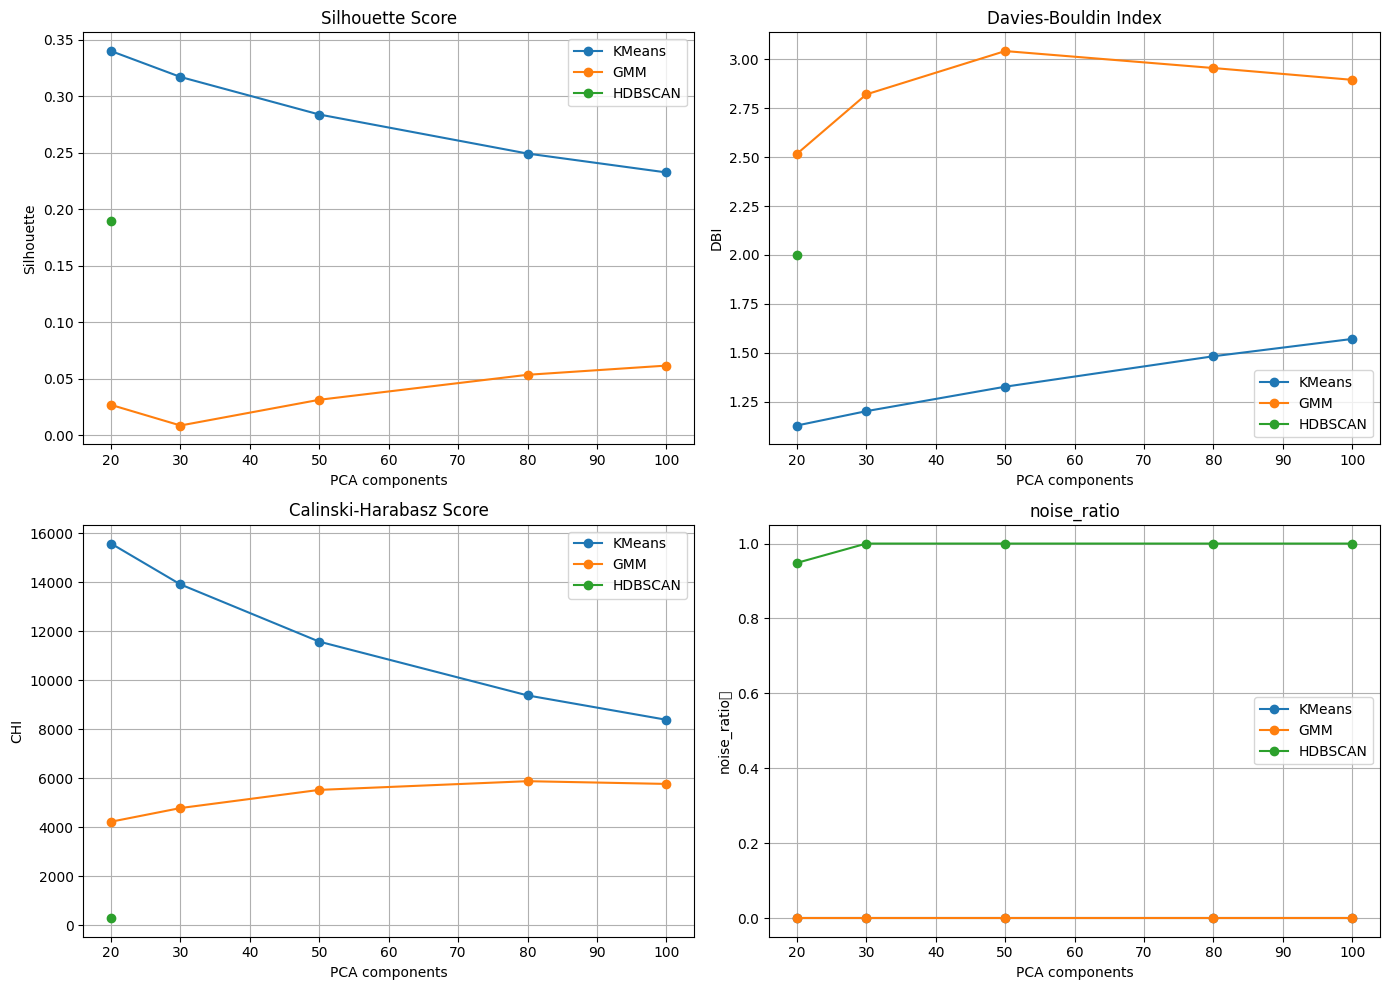

In [25]:
ig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = results_df['model'].unique()

for model in models:
    df_model = results_df[results_df['model'] == model].sort_values('pca_components')
    
    # Silhouette
    axes[0, 0].plot(
        df_model['pca_components'],
        df_model['silhouette'],
        marker='o',
        label=model
    )
    
    # Davies-Bouldin
    axes[0, 1].plot(
        df_model['pca_components'],
        df_model['davies_bouldin'],
        marker='o',
        label=model
    )
    
    # Calinski-Harabasz
    axes[1, 0].plot(
        df_model['pca_components'],
        df_model['calinski_harabasz'],
        marker='o',
        label=model
    )
    
    # noise_ratio	
    axes[1, 1].plot(
        df_model['pca_components'],
        df_model['noise_ratio'],
        marker='o',
        label=model
    )

# Silhouette
axes[0, 0].set_title('Silhouette Score')
axes[0, 0].set_xlabel('PCA components')
axes[0, 0].set_ylabel('Silhouette')
axes[0, 0].grid(True)
axes[0, 0].legend()

# Davies-Bouldin
axes[0, 1].set_title('Davies-Bouldin Index')
axes[0, 1].set_xlabel('PCA components')
axes[0, 1].set_ylabel('DBI')
axes[0, 1].grid(True)
axes[0, 1].legend()

# Calinski-Harabasz
axes[1, 0].set_title('Calinski-Harabasz Score')
axes[1, 0].set_xlabel('PCA components')
axes[1, 0].set_ylabel('CHI')
axes[1, 0].grid(True)
axes[1, 0].legend()

# noise_ratio	
axes[1, 1].set_title('noise_ratio')
axes[1, 1].set_xlabel('PCA components')
axes[1, 1].set_ylabel('noise_ratio	')
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

По результатам сравнения моделей на разных размерностях PCA наилучшие значения внутренних метрик показал KMeans. Для него при всех протестированных значениях числа компонент формировалось ровно 3 кластера без шума, а качество кластеризации оставалось наиболее стабильным. Лучший результат был получен при PCA = 20, где достигались максимальный Silhouette = 0.3399, минимальный Davies-Bouldin = 1.1283 и максимальный Calinski-Harabasz = 15585.19 среди всех моделей.

Модель GMM также выделяла 3 кластера без шума, однако по всем метрикам заметно уступала KMeans. Значения silhouette у GMM оставались очень низкими, что говорит о слабом разделении кластеров. Поэтому GMM в данной задаче оказался менее подходящим.

Алгоритм HDBSCAN показал наихудший результат: при PCA = 20 он находил только 2 кластера, при этом около 94.8% объектов относил к шуму, а при PCA = 30, 50, 80, 100 вообще помечал шумом 100% наблюдений, из-за чего метрики качества не вычислялись. Это означает, что при выбранных параметрах HDBSCAN не смог выявить устойчивую структуру в данных.

Также видно, что с ростом числа компонент PCA качество у KMeans постепенно ухудшалось: silhouette снижался, Davies-Bouldin увеличивался, а Calinski-Harabasz уменьшался. Это показывает, что наиболее удачным оказалось более компактное представление данных, а именно снижение размерности до 20 компонент.

Итог: лучшей моделью для данной задачи стал KMeans после PCA на 20 компонент, так как именно эта комбинация обеспечила наиболее качественное и устойчивое разбиение данных на 3 кластера.

### KMeans

In [26]:
prep = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20, random_state=42))
])

X_pca = prep.fit_transform(X_raw)
print("NaN after preprocessing:", np.isnan(X_pca).sum())
print(f"После PCA: {X_pca.shape[1]} признаков")

NaN after preprocessing: 0
После PCA: 20 признаков


Посмотрим качество выбранной модели на разном количестве кластеров

In [27]:
k_results = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_pca)
    
    k_results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X_pca, labels),
        'davies_bouldin': davies_bouldin_score(X_pca, labels),
        'calinski_harabasz': calinski_harabasz_score(X_pca, labels)
    })

k_results_df = pd.DataFrame(k_results)
k_results_df

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,2.763843e+06,0.496049,0.891163,19987.811874
1,3,2.198221e+06,0.339935,1.128286,15585.185108
2,4,1.952998e+06,0.220590,1.402630,12676.800642
3,5,1.784082e+06,0.156163,1.610977,10962.935043
4,6,1.693952e+06,0.142950,1.666660,9486.378040
5,7,1.606155e+06,0.144396,1.420978,8550.948033
6,8,1.543749e+06,0.125639,1.578152,7760.879523


Визуализируем результат.

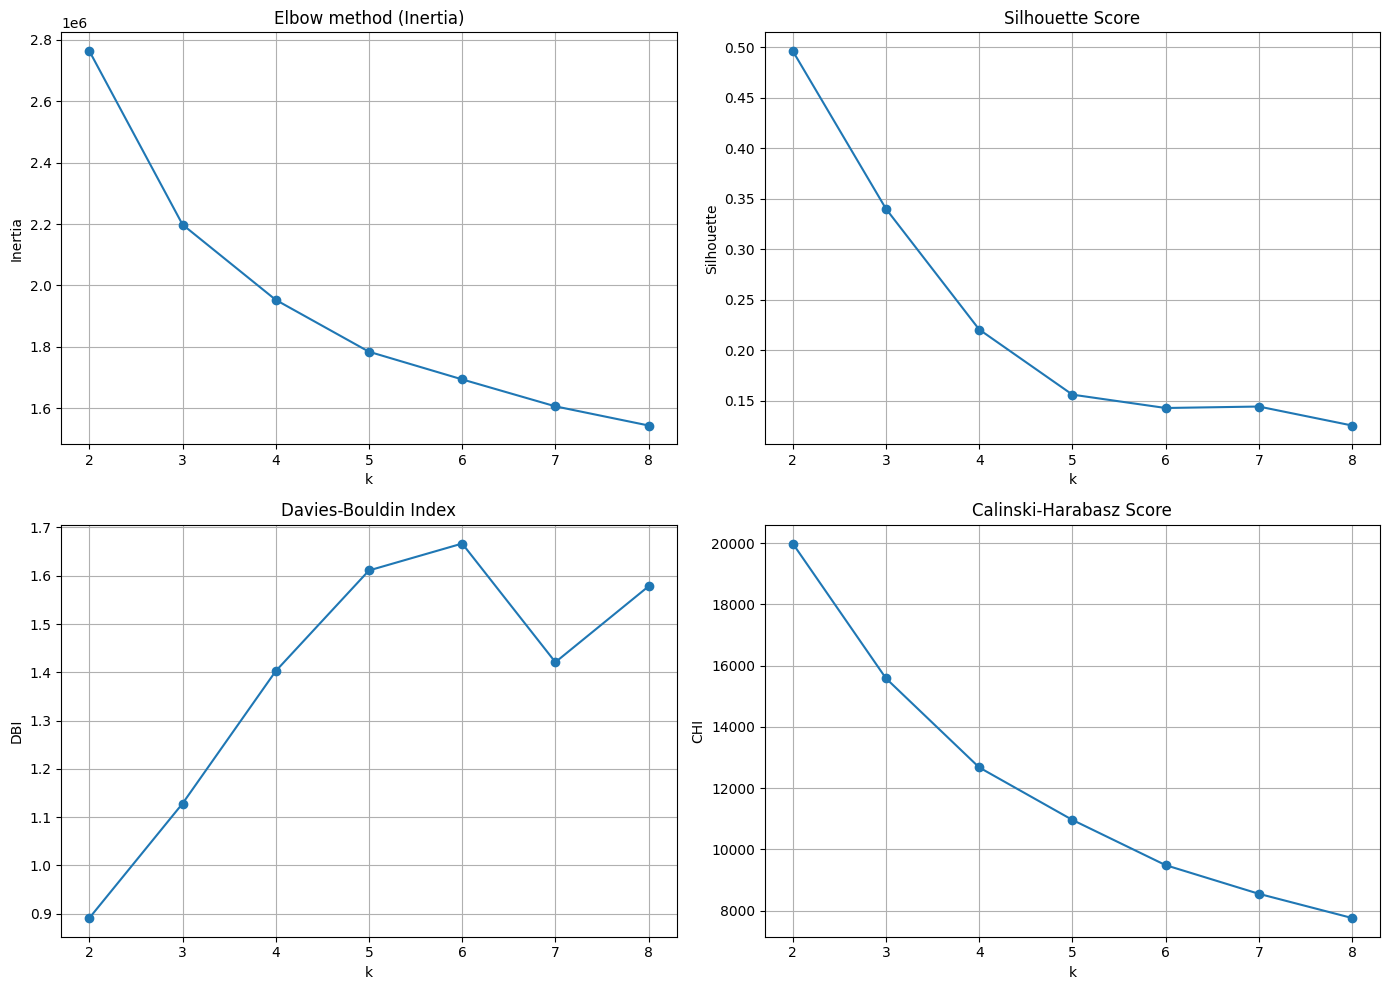

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Inertia
axes[0, 0].plot(k_results_df['k'], k_results_df['inertia'], marker='o')
axes[0, 0].set_title('Elbow method (Inertia)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].grid(True)

# Silhouette
axes[0, 1].plot(k_results_df['k'], k_results_df['silhouette'], marker='o')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].grid(True)

# Davies-Bouldin
axes[1, 0].plot(k_results_df['k'], k_results_df['davies_bouldin'], marker='o')
axes[1, 0].set_title('Davies-Bouldin Index')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('DBI')
axes[1, 0].grid(True)

# Calinski-Harabasz
axes[1, 1].plot(k_results_df['k'], k_results_df['calinski_harabasz'], marker='o')
axes[1, 1].set_title('Calinski-Harabasz Score')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('CHI')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

По условиям задачи необходимо кластеризовать признаки/сигналы на три кластера по типу сигналов: два кластера отображают типы сигналов (гамма-кванты или нейтроны), третий кластер представляет себя группу сигналов, которые не поддаются кластеризации. (Нумерация кластеров с 0: 0,1,2). Поэтому я приняла решение:

- выделить 2 основных кластера,
- определить объекты, которые плохо к ним относятся,
- отправить такие объекты в кластер 2 как “неподдающиеся кластеризации”.

Данное решение основано на предоставленной визуализации, где очевидно, что качество кластеризации выше именно на 2 кластерах, и полностью соответствует ТЗ. Но у этого подхода есть и свои особенности: это наличие порога, по которому будем относить объекты к кластеру либо шуму. В качестве основы возьмем расстояние до ближайшего центроида, чем больше расстояние, тем большая вероятность отнесения объекта к шуму.

In [29]:
# kmeans для 2 кластеров
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=20, random_state=42)
labels_2 = kmeans.fit_predict(X_pca)

# расстояние до центра
distances = kmeans.transform(X_pca)  # shape: (n_samples, 2)
min_dist = distances.min(axis=1)     # расстояние до центра

# определим порог (расстояние) по которому будем выделять третий кластер (меняя порог можно также влиять на метрику!!!)
threshold = np.percentile(min_dist, 95)   

# метки: 0,1 предсказываемые кластеры, 2 для шума
labels_final = labels_2.copy()
labels_final[min_dist > threshold] = 2

mapping = {0: 1, 1: 0, 2: 2}

labels_final_perm = np.array([mapping[x] for x in labels_final])

# сабмит
submission_ = pd.DataFrame({
    'index': np.arange(len(labels_final_perm)),
    'cluster': labels_final_perm
})

print(submission_['cluster'].value_counts().sort_index())
print(submission_.head())

cluster
0     3520
1    18785
2     1174
Name: count, dtype: int64
   index  cluster
0      0        1
1      1        1
2      2        1
3      3        1
4      4        1


Еще одна сложность, с которой столкнулись, это то, что метки, выдаваемые KMeans, не совпадают автоматически с целевыми номерами классов, пришлось опытным путем проводить перенумерацию, ориентируясь на метрику.

In [31]:
submission_.to_csv('submission_.csv', index=False)

print(f"Строк: {len(submission_)}")
print(submission_.head(10))

Строк: 23479
   index  cluster
0      0        1
1      1        1
2      2        1
3      3        1
4      4        1
5      5        1
6      6        1
7      7        1
8      8        1
9      9        1


## Выводы:

Условие задачи предполагает наличие трёх итоговых классов, из которых два соответствуют физически интерпретируемым типам сигналов, а третий представляет собой группу сигналов, не поддающихся уверенной кластеризации. В связи с этим задача была интерпретирована не как поиск трёх равноправных компактных кластеров, а как выделение двух основных кластеров с последующим отнесением наиболее нетипичных наблюдений в отдельный третий класс. Для реализации такого подхода использовался алгоритм KMeans с числом кластеров 2, после чего для каждого объекта вычислялось расстояние до ближайшего центроида. Наблюдения с наибольшими расстояниями до центров рассматривались как плохо принадлежащие к обоим основным типам и относились к третьему классу, интерпретируемому как шум или некластеризуемые сигналы.

В работе была решена задача кластеризации сигналов на 3 кластера. Для предобработки данных использовались стандартизация признаков (StandardScaler) и снижение размерности методом главных компонент (PCA). После этого кластеризация выполнялась алгоритмом KMeans с числом кластеров 2.

Первоначально датасет содержал 504 признака, часть из которыз коррелировала между собой.Вообще какой-то особой обработки не требовалось, только удаление стационарных столбцов, и масштабирование данных

Для борьбы с высокой размерностью применялся рекомендованный справочной литературой PCA, который позволил сократить число признаков и уменьшить шум, сохранив наиболее значимую информацию. Это упростило структуру данных и улучшило качество кластеризации по сравнению с использованием исходного пространства признаков.

Были изучены разные модели, но после обучения и сравнения полученных метрик остановилась на KMeans. Также после изучения работы модели с разным количеством кластеров, было прнято решение о кластеризации на 2 кластера, а третий необходимый кластер формировать из сомнительных/шумовых объектов. Алгоритм оказался достаточно прост, но эффективен. Стартовая метрика составила 0,533 на лидерборде с большим потенциалом дальнейшего улучшения. Данная модель может быть использована в качестве базовой модели.

Также было установлено, что важную роль играет перенумерация кластеров, так как метки, выдаваемые KMeans, не совпадают автоматически с целевыми номерами классов. Лучшая метрика была получена после перестановки меток.

Что можно улучшить дальше:

- подобрать оптимальное число компонент PCA;

- изменить порог, по которому, производился отбор в кластеры;

- протестировать другие методы кластеризации, например Gaussian Mixture или Agglomerative Clustering;

- исследовать более сложные способы выявления структуры данных и выбросов;

- создать новые признаки;

- произвести отбраковку шумов;

- провести более широкий перебор гиперпараметров.